## Data investigation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import datasets, model_selection, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("Cars.csv")
print(df.info())
pd.set_option("display.max_columns", None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## Data transformation and data type changes


In [ ]:
#For floats to look pretty
pd.options.display.float_format = '{:g}'.format

In [ ]:
#Remain only the name of the brand of the car, and change the name of the column to brand
df["brand"] = df["name"].str.split().str[0]
df.drop(columns=["name"], inplace=True)

In [ ]:
#Fuel remove
df = df[df["fuel"] != "CNG"]
df = df[df["fuel"] != "LPG"]

In [ ]:
#Owner replace with numbers
df["owner"] = df["owner"].map({"First Owner": 1, "Second Owner": 2, "Third Owner": 3,
    "Fourth & Above Owner": 4,"Test Drive Car":5})

In [ ]:
#Drop entities where owner was "Test Drive Cars"
df = df[df["owner"] != 5]

In [ ]:
#Dropping down the units and changing data type for mileage
df["mileage"] = df["mileage"].str.split().str[0]
df["mileage"] = df["mileage"].astype(float)

In [ ]:
#Engine dropping CC and changing the data type
df["engine"] = df["engine"].str.split().str[0]
df["engine"] = df["engine"].astype("Int64")

In [ ]:
#max_power dropping CC and data typpe change + if there was not a value befor bhp change to nan
df["max_power"] = df["max_power"].str.split().str[0]
df["max_power"] = df["max_power"].replace("bhp", np.nan)
df["max_power"] = df["max_power"].astype(float)

In [ ]:
#Dropping torque column
df.drop(columns=["torque"], inplace=True)

In [ ]:
#Keeping the order as in the instruction for clairty
df = df[["brand",  "year", "selling_price", "km_driven", "fuel", "seller_type",
        "transmission", "owner", "mileage", "engine", "max_power", "seats"]]

In [ ]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74,5
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78,5
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23,1396,90,5
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          8028 non-null   object 
 1   year           8028 non-null   int64  
 2   selling_price  8028 non-null   int64  
 3   km_driven      8028 non-null   int64  
 4   fuel           8028 non-null   object 
 5   seller_type    8028 non-null   object 
 6   transmission   8028 non-null   object 
 7   owner          8028 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   Int64  
 10  max_power      7820 non-null   float64
 11  seats          7814 non-null   float64
dtypes: Int64(1), float64(3), int64(4), object(4)
memory usage: 823.2+ KB
None


## EDA

In [ ]:
df.columns

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')

### Univariate analyis

<Axes: xlabel='fuel', ylabel='count'>

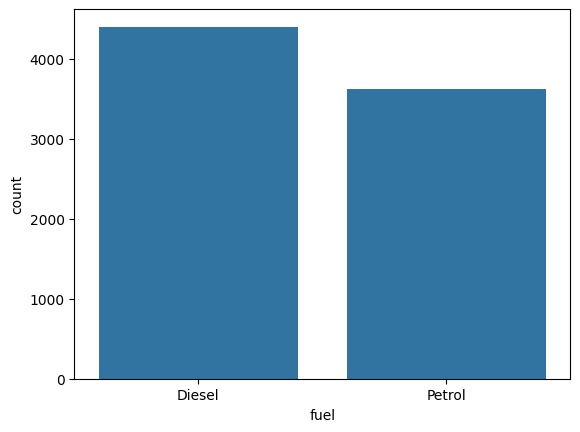

In [ ]:
sns.countplot(x="fuel", data=df)

Daset contains more cars that consume diesel

<Axes: xlabel='seller_type', ylabel='count'>

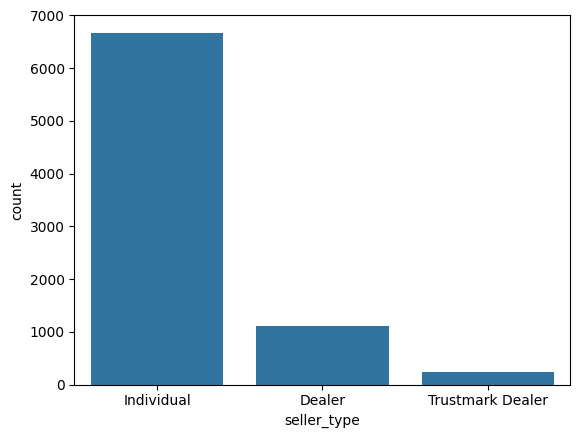

In [ ]:
sns.countplot(x="seller_type", data=df)

The biggest selling group are individual sellers, the smallest trustmerk dealers

<Axes: xlabel='transmission', ylabel='count'>

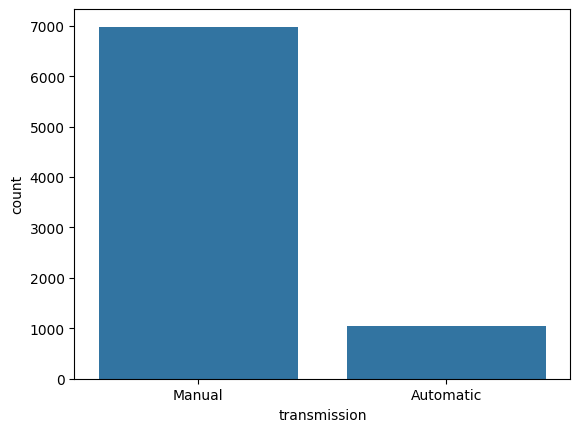

In [ ]:
sns.countplot(x="transmission", data=df)

The majority of the cars in the database are the ones with manual transmission

<Axes: xlabel='owner', ylabel='count'>

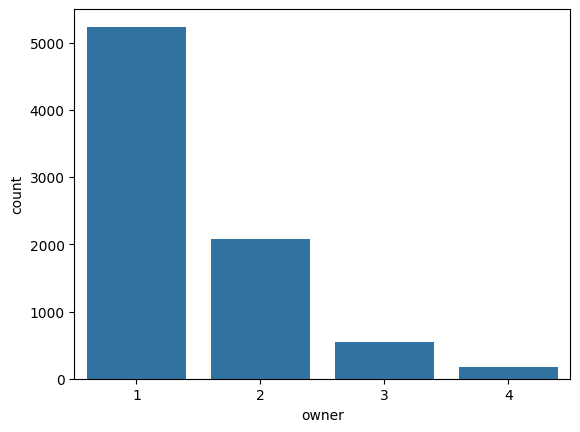

In [ ]:
sns.countplot(x="owner", data=df)

The dataset consists mostly of cars with one previous owner, with the number of cars decreasing as the number of previous owners increases

<Axes: xlabel='selling_price', ylabel='Count'>

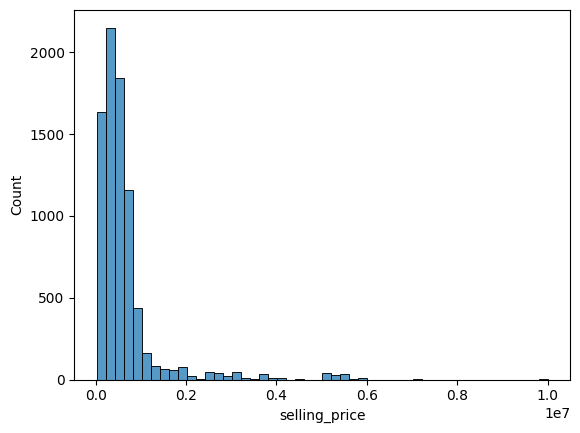

In [ ]:
sns.histplot(df["selling_price"], bins=50)

Selling prices are skewed to the left

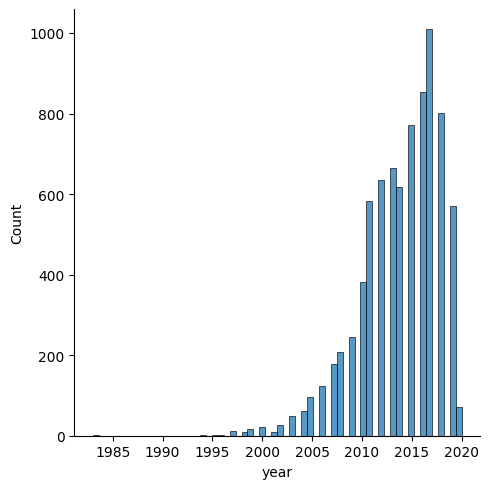

In [ ]:
sns.displot(df["year"])

Year of production plot is skewed to the right

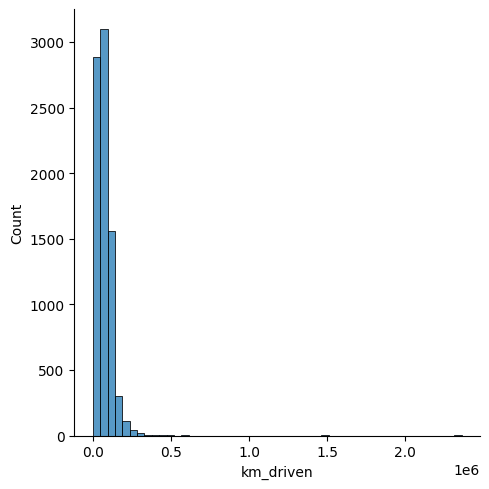

In [ ]:
sns.displot(df["km_driven"], bins=50)

Most cars have low amount of kilometers driven

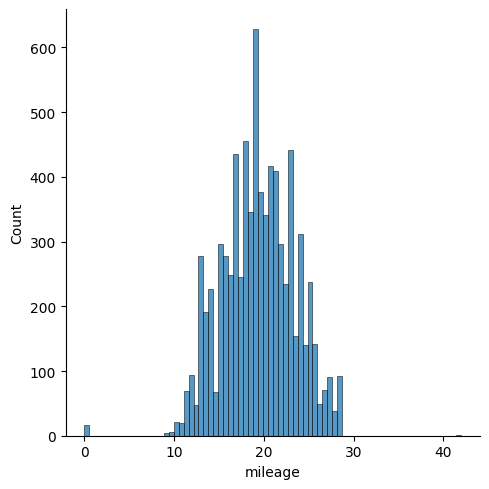

In [ ]:
sns.displot(df["mileage"])

Mileage has normal distribution

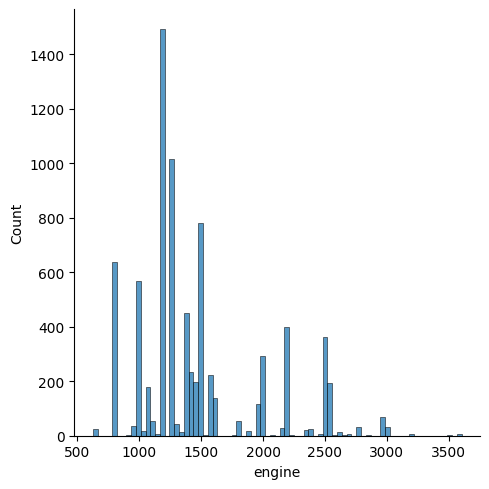

In [ ]:
sns.displot(df["engine"])

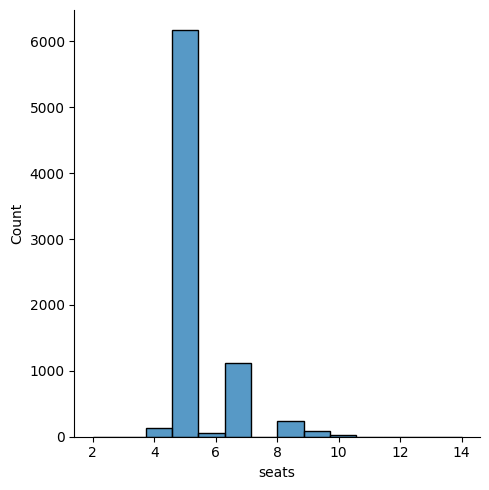

In [ ]:
sns.displot(df["seats"])

Majority of the cars in the database has 5 seats, the smallest seats number is 4, and the biggest is 11

### Multivariate analysis

<Axes: xlabel='year', ylabel='selling_price'>

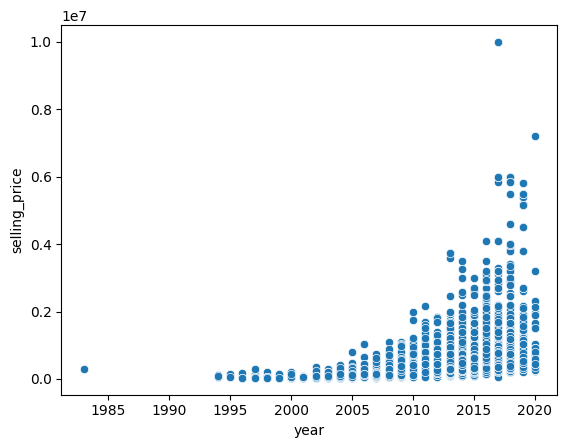

In [ ]:
sns.scatterplot(x="year", y="selling_price", data=df)

Younger the car higher the price, with two outliers spots in ~2018 and ~2020

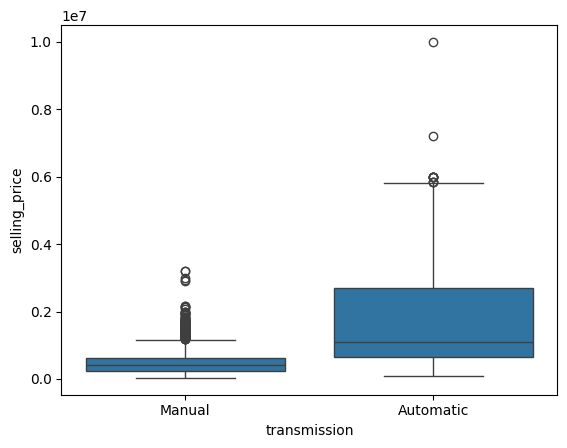

In [ ]:
sns.boxplot(x="transmission", y="selling_price", data=df)
plt.show()

Automatic cars are pricier than the ones with manual transmission

### Correlation Matrix

In [ ]:
df.columns

Index(['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')

In [ ]:
#Encoding the labels for columns fuel and transmission for the correlation matrix
le_fuel = LabelEncoder()
df["fuel"] = le_fuel.fit_transform(df["fuel"])
le_fuel.classes_

array(['Diesel', 'Petrol'], dtype=object)

In [ ]:
le_transmission = LabelEncoder()
df["transmission"] = le_transmission.fit_transform(df["transmission"])
le_transmission.classes_

array(['Automatic', 'Manual'], dtype=object)

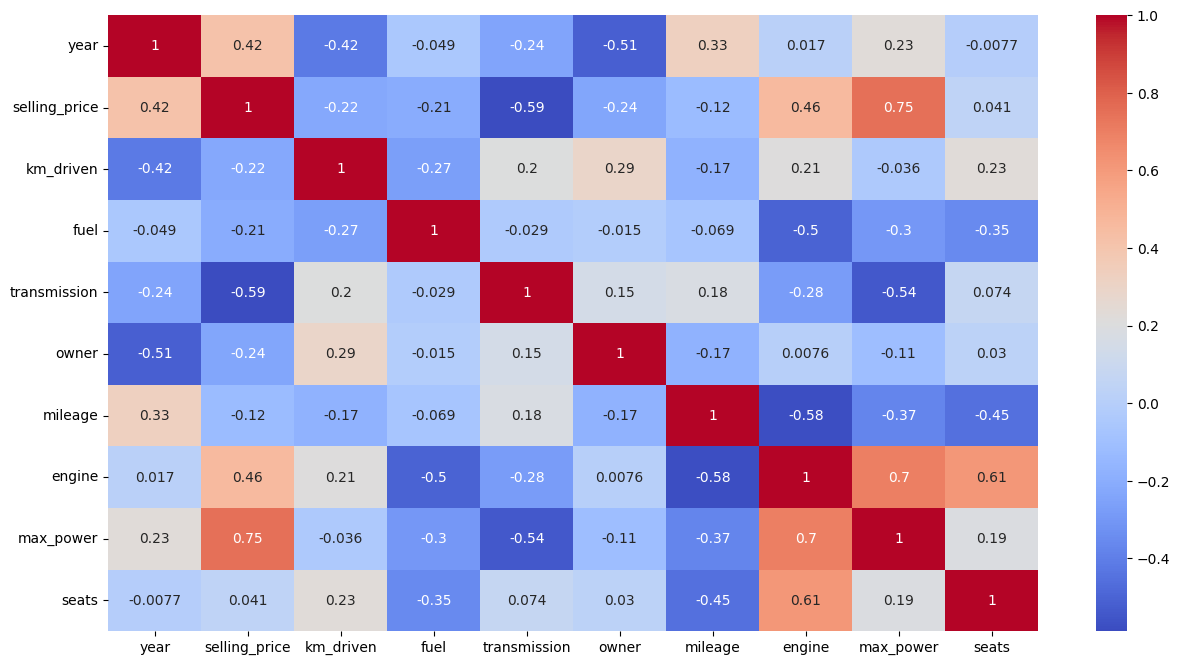

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Over all the features are not strongly correlated. Selling price is strongly correlated with max power, transmission, engine, and year.

# Preparation for interference


## Duplicates verification
 If there are any, it is necessary to take care of it, because model can be tested in already seen samples

In [ ]:
df.duplicated().sum()

np.int64(1220)

In [ ]:
#Manual verification if the cars are actually the same or similar
duplicates = df[df.duplicated(keep=False)]
duplicates.sort_values(by=list(df.columns))

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2129,Audi,2014,1850000,76131,0,Individual,0,1,13.22,2967,241.4,5
7775,Audi,2014,1850000,76131,0,Individual,0,1,13.22,2967,241.4,5
1977,Audi,2017,2825000,22000,0,Dealer,0,1,15.73,1968,174.33,5
7324,Audi,2017,2825000,22000,0,Dealer,0,1,15.73,1968,174.33,5
131,Audi,2018,3975000,31800,0,Dealer,0,1,17.01,1968,188,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6558,Volvo,2019,3800000,20000,0,Individual,0,1,18,1969,190,5
6577,Volvo,2019,3800000,20000,0,Individual,0,1,18,1969,190,5
6693,Volvo,2019,3800000,20000,0,Individual,0,1,18,1969,190,5
6963,Volvo,2019,3800000,20000,0,Individual,0,1,18,1969,190,5


In [ ]:
#Yes, they are the same- dropping them, and than reseting indexes
df = df.drop_duplicates()
df = df.reset_index(drop=True)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6808 entries, 0 to 6807
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          6808 non-null   object 
 1   year           6808 non-null   int64  
 2   selling_price  6808 non-null   int64  
 3   km_driven      6808 non-null   int64  
 4   fuel           6808 non-null   int64  
 5   seller_type    6808 non-null   object 
 6   transmission   6808 non-null   int64  
 7   owner          6808 non-null   int64  
 8   mileage        6607 non-null   float64
 9   engine         6607 non-null   Int64  
 10  max_power      6610 non-null   float64
 11  seats          6607 non-null   float64
dtypes: Int64(1), float64(3), int64(6), object(2)
memory usage: 645.0+ KB
None


## Splitting

In [ ]:
#The predicted feature will be the car price and accordingly to the tip it will be the logaryth of the price forstability
y = np.log(df["selling_price"])

In [ ]:
#The features
x = df.drop(columns=["selling_price"])

In [ ]:
#Splitting by standard 8:2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

## Imputation

For columns: "mileage", "engine", "max_power", "seats" based on the normality the mean/median imputation will be performed. The histograms function is to define the normality

<Axes: >

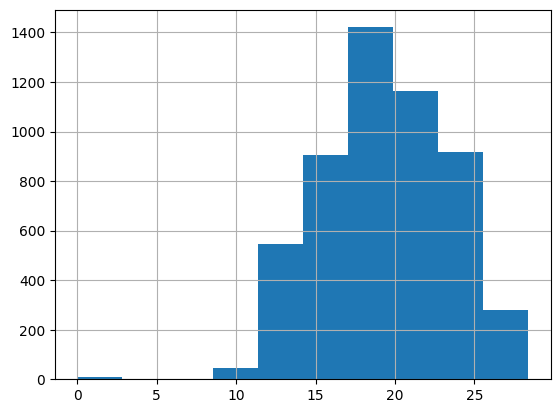

In [ ]:
x_train["mileage"].hist()

<Axes: >

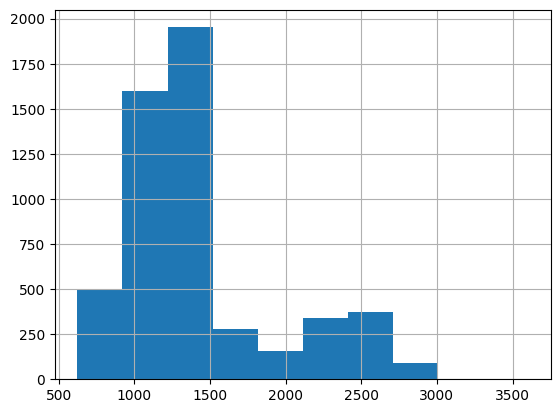

In [ ]:
x_train["engine"].hist()

<Axes: >

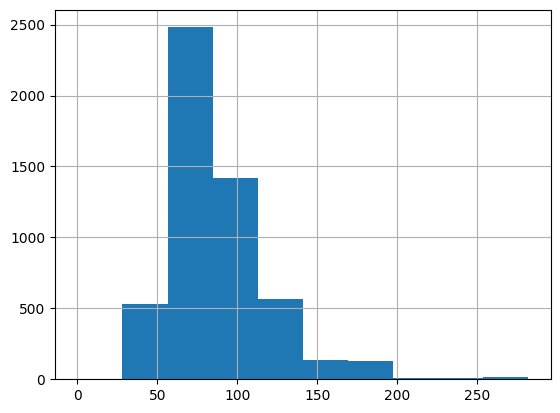

In [ ]:
x_train["max_power"].hist()

<Axes: >

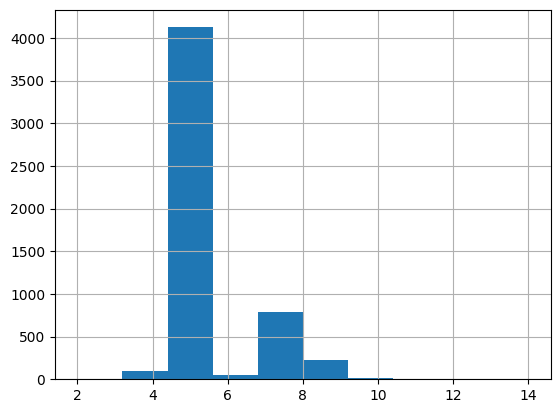

In [ ]:
x_train["seats"].hist()

In [ ]:
#For mileage mean is used because it has near normal distribution
mean_mileage = x_train["mileage"].mean()
x_train["mileage"] = x_train["mileage"].fillna(mean_mileage)
x_test["mileage"] = x_test["mileage"].fillna(mean_mileage)

Skewed graphs -> Median based imputations

In [ ]:
median_engine = x_train["engine"].median()
x_train["engine"] = x_train["engine"].fillna(median_engine)
x_test["engine"] = x_test["engine"].fillna(median_engine)

In [ ]:
median_max_power = x_train["max_power"].median()
x_train["max_power"] = x_train["max_power"].fillna(median_max_power)
x_test["max_power"] = x_test["max_power"].fillna(median_max_power)

In [ ]:
#The median of the setas is rounded up to avoid partial seats
median_seats = round(x_train["seats"].median())
x_train["seats"] = x_train["seats"].fillna(median_seats)
x_test["seats"] = x_test["seats"].fillna(median_seats)

Foe non-obligatory cathegorical features, most represented- being in the greatest amount, "modes" of each fature will be used as a default value.

In [ ]:
print(df.loc[x_train.index, "fuel"].value_counts())
print(df.loc[x_train.index, "seller_type"].value_counts())
print(df.loc[x_train.index, "owner"].value_counts())
mode_fuel = df.loc[x_train.index, "fuel"].mode()[0]
mode_seller_type = df.loc[x_train.index, "seller_type"].mode()[0]
mode_owner = df.loc[x_train.index, "owner"].mode()[0]

fuel
0    2978
1    2468
Name: count, dtype: int64
seller_type
Individual          4884
Dealer               536
Trustmark Dealer      26
Name: count, dtype: int64
owner
1    3325
2    1551
3     438
4     132
Name: count, dtype: int64


## Encoding

In [ ]:
#To verify if One Hot Encoding is good way for the object columns
print(x_train["brand"].unique())
print(x_train["fuel"].unique())
print(x_train["seller_type"].unique())
print(x_train["transmission"].unique())

['BMW' 'Maruti' 'Tata' 'Hyundai' 'Honda' 'Skoda' 'Toyota' 'Mahindra'
 'Jeep' 'Renault' 'Fiat' 'Volkswagen' 'Nissan' 'Ford' 'Chevrolet'
 'Mercedes-Benz' 'Ambassador' 'Datsun' 'Audi' 'Isuzu' 'Force' 'Volvo'
 'Daewoo' 'Mitsubishi' 'Jaguar' 'Ashok' 'Land' 'MG' 'Peugeot' 'Kia' 'Opel'
 'Lexus']
[1 0]
['Dealer' 'Individual' 'Trustmark Dealer']
[0 1]


One-Hot Encoding will be appropriate because the number of unique values in each of these four columns is reasonable

In [ ]:
x_train = pd.get_dummies(x_train, columns=["brand"])
x_test = pd.get_dummies(x_test, columns=["brand"])

In [ ]:
x_train = pd.get_dummies(x_train, columns=["fuel"])
x_test = pd.get_dummies(x_test, columns=["fuel"])

In [ ]:
x_train = pd.get_dummies(x_train, columns=["seller_type"])
x_test = pd.get_dummies(x_test, columns=["seller_type"])

In [ ]:
x_train = pd.get_dummies(x_train, columns=["transmission"])
x_test = pd.get_dummies(x_test, columns=["transmission"])

In [ ]:
#If columns are in the train, they also have to be present in the test, even in the case when none of the samples has this feature
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

## Scalling

Skaling allows to diminish the differences of ranges between features. Scalling is used for the numerical features-> not the ones that were encoded in previous section, plus owner column was excluded because number is actual ordered cathegory

In [ ]:
scaler_year = StandardScaler()
x_train["year"] = scaler_year.fit_transform(x_train[["year"]])
x_test["year"] = scaler_year.transform(x_test[["year"]])

In [ ]:
scaler_km = StandardScaler()
x_train["km_driven"] = scaler_km.fit_transform(x_train[["km_driven"]])
x_test["km_driven"] = scaler_km.transform(x_test[["km_driven"]])

In [ ]:
scaler_mileage = StandardScaler()
x_train["mileage"] = scaler_mileage.fit_transform(x_train[["mileage"]])
x_test["mileage"] = scaler_mileage.transform(x_test[["mileage"]])

In [ ]:
scaler_engine = StandardScaler()
x_train["engine"] = scaler_engine.fit_transform(x_train[["engine"]])
x_test["engine"] = scaler_engine.transform(x_test[["engine"]])

In [ ]:
scaler_power = StandardScaler()
x_train["max_power"] = scaler_power.fit_transform(x_train[["max_power"]])
x_test["max_power"] = scaler_power.transform(x_test[["max_power"]])

In [ ]:
scaler_seats = StandardScaler()
x_train["seats"] = scaler_seats.fit_transform(x_train[["seats"]])
x_test["seats"] = scaler_seats.transform(x_test[["seats"]])

# Modelling

4 different types of algorithms will be used: Linear Regression, Random Forest, Decision Tree and Support Vector Regression.
To obtained a final result the exponential function is used.
To ensure stability 5-time cross validation is used.
For final score, default regression metrics is used- R Squared- coefficient of determination, which is describes the difference of prediction and case when model simply predicts the average value.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
linear = LinearRegression()
linear.fit(x_train, y_train)
p_linear = linear.predict(x_test)
#Exponential because logarythm was used for trainig, the reverse equation needed to obtain the actual price
p_linear = np.exp(p_linear)
#Performing 5-time cross-validation to prevent overfitting and ensure stability
s_linear = cross_val_score(linear, x_train, y_train, cv=5)

In [ ]:
forest = RandomForestRegressor()
forest.fit(x_train, y_train)
p_forest = forest.predict(x_test)
p_forest = np.exp(p_forest)

s_forest = cross_val_score(forest, x_train, y_train, cv=5)

In [ ]:
tree = DecisionTreeRegressor()
tree.fit(x_train, y_train)
p_tree = tree.predict(x_test)
p_tree = np.exp(p_tree)

s_tree = cross_val_score(tree, x_train, y_train, cv=5)

In [ ]:
svm = SVR()
svm.fit(x_train, y_train)
p_svm = svm.predict(x_test)
p_svm = np.exp(p_svm)

s_svm = cross_val_score(svm, x_train, y_train, cv=5)

In [ ]:
#Obtaining back the real value of the price
y_test_real = np.exp(y_test)

Reporting all three metrics-  MSE, RMSE and R², for every of 4 models

In [ ]:
mse_linear = mean_squared_error(y_test_real, p_linear)
rmse_linear = root_mean_squared_error(y_test_real, p_linear)
r2_linear = r2_score(y_test_real, p_linear)

In [ ]:
mse_forest = mean_squared_error(y_test_real, p_forest)
rmse_forest = root_mean_squared_error(y_test_real, p_forest)
r2_forest = r2_score(y_test_real, p_forest)

In [ ]:
mse_tree = mean_squared_error(y_test_real, p_tree)
rmse_tree = root_mean_squared_error(y_test_real, p_tree)
r2_tree = r2_score(y_test_real, p_tree)

In [ ]:
mse_svm = mean_squared_error(y_test_real, p_svm)
rmse_svm = root_mean_squared_error(y_test_real, p_svm)
r2_svm = r2_score(y_test_real, p_svm)

In [ ]:
print("Linear Regression:")
print("MSE:", round(mse_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²:", round(r2_linear, 2))

print("\nRandom Forest:")
print("MSE:", round(mse_forest, 2))
print("RMSE:", round(rmse_forest, 2))
print("R²:", round(r2_forest, 2))

print("\nDecision Tree:")
print("MSE:", round(mse_tree, 2))
print("RMSE:", round(rmse_tree, 2))
print("R²:", round(r2_tree, 2))

print("\nSVM:")
print("MSE:", round(mse_svm, 2))
print("RMSE:", round(rmse_svm, 2))
print("R²:", round(r2_svm, 2))

Linear Regression:
MSE: 46873583691.39
RMSE: 216503.08
R²: 0.86

Random Forest:
MSE: 54020446373.52
RMSE: 232422.99
R²: 0.84

Decision Tree:
MSE: 58427617536.81
RMSE: 241718.05
R²: 0.83

SVM:
MSE: 101393936642.84
RMSE: 318424.15
R²: 0.7


# Report

### Build-in answear

3 out 4 used algorithms have build-in tools that can help answear the question which features are the most important.

Linear Regression coefficient– number showing the direction and strength of the relationship between each feature and the prediction

Random Forest feature importance– number showing how much each feature contributes to reducing prediction error across forest

Decision Tree feature importance- number showing how much each feature contributes to reducing prediction error in the decision tree

<Axes: >

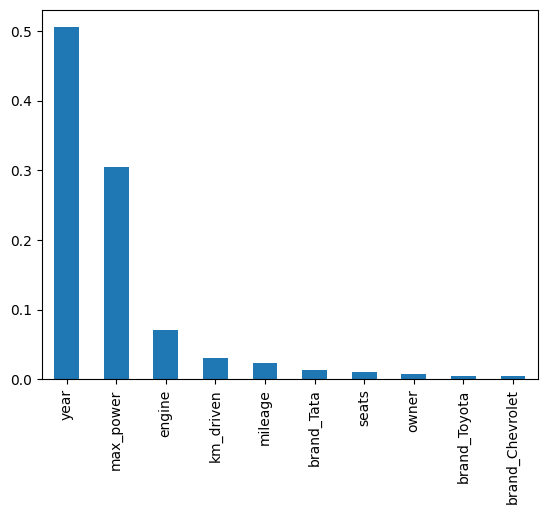

In [ ]:
i_forest = pd.Series(forest.feature_importances_, index=x_train.columns)
i_forest = i_forest.sort_values(ascending=False)
i_forest.nlargest(10).plot(kind="bar")

<Axes: >

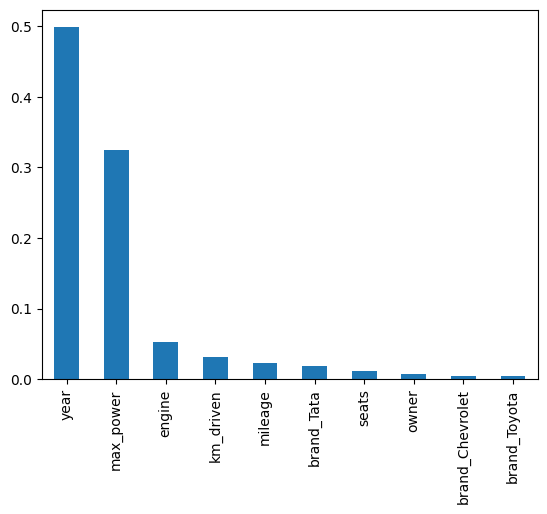

In [ ]:
i_tree = pd.Series(tree.feature_importances_, index=x_train.columns)
i_tree = i_tree.sort_values(ascending=False)
i_tree.nlargest(10).plot(kind="bar")

<Axes: >

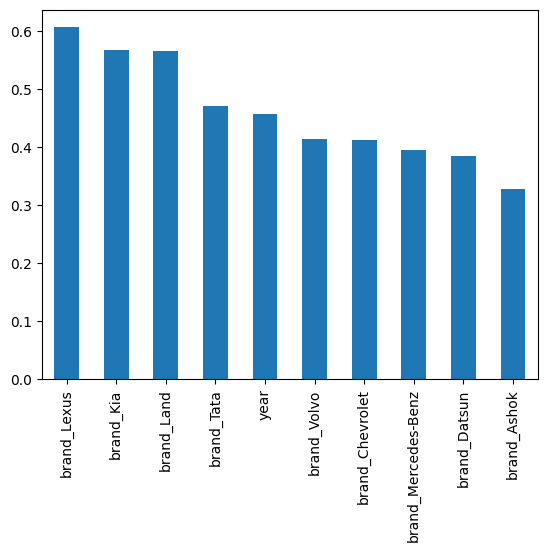

In [ ]:
i_linear = pd.Series(abs(linear.coef_), index=x_train.columns)
i_linear = i_linear.sort_values(ascending=False)
i_linear.nlargest(10).plot(kind="bar")

## Report

The dataset was over all well constructed, it consisted 7 numerical features and 4 cathegorical, it did not have many missing values what made it significant and valuable. There were multiple duplicates within the dataset and dropping the duplicates was imporstant step to exclude data leakage. All simple models predicted car prices well and performed better than using the average price. A direct comparison of the models based only on basic metrics is not fully correct, although the obtained R² scores were 0.88 for Linear Regression, 0.87 for Random Forest, 0.86 for Decision Tree, and 0.73 for SVM. The MSE and RMSE results varied between the models, with Linear Regression obtaining MSE of 41.05 billion and RMSE of 202,614, Random Forest 45.82 billion and 214,056, Decision Tree 47.89 billion and 218,828, and SVM 92.55 billion and 304,219, respectively. The features importance analysis allowed to state that for Decision Tree and Random Forest Year and max_power were the most important features- they influenced the decicion significantly. For Linear Regression, brand features have the largest coefficients.

# Inference

Saving everything that will be needed for the deployment

In [ ]:
inference = {
    "model": linear,
    "columns": x_train.columns.tolist(),
    "mean_mileage": mean_mileage,
    "median_seats": median_seats,
    "mode_fuel": mode_fuel,
    "mode_seller_type": mode_seller_type,
    "mode_owner": mode_owner,
    "scaler_year": scaler_year,
    "scaler_km": scaler_km,
    "scaler_mileage": scaler_mileage,
    "scaler_engine": scaler_engine,
    "scaler_power": scaler_power,
    "scaler_seats": scaler_seats
}

In [ ]:
joblib.dump(inference, "car_price_model.pkl")

['car_price_model.pkl']